# Mejora 8 - Ensambles con entrenamiento, validación y prueba

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

Este notebook responde a los comentarios del profesor sobre los modelos del proyecto:

1. Usar una partición en **entrenamiento, validación y prueba**.
2. **Medir el sesgo** de los modelos.
3. Revisar los ensambles siguiendo la **práctica de ensambles** (Práctica 2, Actividad 4).
4. Construir la votación con los **mejores modelos**.

La estructura sigue los pasos de la práctica:

| Paso de la práctica | Sección de este notebook |
|:---|:---|
| Partición 60/20/20 estratificada; el conjunto de prueba solo se usa al final | 2 |
| Modelos base optimizados con `GridSearchCV` (validación cruzada estratificada de 5 particiones) | 4 |
| Comparación entre entrenamiento y validación (sobreajuste) | 5 |
| Random Forest, Gradient Boosting, votación dura y suave, y stacking | 6 |
| Matrices de confusión, métricas y curvas ROC y de precisión-sensibilidad en entrenamiento y validación | 7 |
| Tabla comparativa en validación y elección del mejor | 8 |
| Evaluación final en el conjunto de prueba | 9 |

Siguiendo la indicación del curso, el primer paso usa los modelos vistos en clase (regresión logística, Naive Bayes, árbol de decisión, KNN, Random Forest, votación y stacking). Solo después se agregan los modelos que parten de ellos y que funcionaron mejor en los notebooks anteriores (NB-LR y el modelo en dos etapas).

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Todo se basa en bolsas de palabras, TF-IDF y n-gramas. |
| Usar únicamente modelos de scikit-learn. | Todos los clasificadores son de scikit-learn. `NBRegresionLogistica` y `ModeloDosEtapasNBLR` son clases propias que solo combinan `LogisticRegression` y `MultinomialNB`. |
| No usar `eval.csv` para entrenar. | `eval.csv` solo se usa para generar el envío a la competencia. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 13). |

## 1. Importación de librerías

In [1]:
import os
import re
import time
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer
from scipy import sparse

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import (HistGradientBoostingClassifier, RandomForestClassifier,
                              StackingClassifier, VotingClassifier)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, ConfusionMatrixDisplay, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, label_binarize
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 180)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos y partición en entrenamiento, validación y prueba

Las 12.000 reseñas etiquetadas se dividen en 60% de entrenamiento (7.200), 20% de validación (2.400) y 20% de prueba (2.400), de forma estratificada para conservar la proporción de clases:

- **Entrenamiento:** para ajustar los modelos y buscar sus hiperparámetros con validación cruzada.
- **Validación:** para comparar los modelos, medir el sobreajuste y elegir el mejor.
- **Prueba:** se usa una sola vez, al final, para estimar el desempeño del modelo elegido.

Esta partición es distinta a la de los notebooks anteriores (80/20), así que las cifras de este notebook no son directamente comparables con las de ellos. Con 2.400 reseñas, el error estándar de una exactitud cercana a 0,90 es de unos 0,6 puntos, así que diferencias menores a eso entre modelos deben leerse con cuidado.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
print('Distribución de clases en train:')
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Distribución de clases en train:


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


In [3]:
X = train[['text']]
y = train['label']

# 60% entrenamiento, 20% validación y 20% prueba, de forma estratificada (como en la Actividad 2 de la práctica)
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size=0.25, stratify=y_resto, random_state=RANDOM_STATE)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Entrenamiento:', X_train.shape, '| Validación:', X_val.shape, '| Prueba:', X_test.shape)
pd.DataFrame({'entrenamiento': y_train.value_counts(normalize=True), 'validación': y_val.value_counts(normalize=True),
              'prueba': y_test.value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3)

Entrenamiento: (7200, 1) | Validación: (2400, 1) | Prueba: (2400, 1)


,entrenamiento,validación,prueba
label,,,
negativo,0.351,0.351,0.351
neutral,0.298,0.298,0.298
positivo,0.351,0.351,0.351


## 3. Preprocesamiento y representación

Se reutiliza el preprocesamiento de los notebooks anteriores: limpieza del texto (minúsculas, sin tildes, signos ni números, con stemming) y la representación por bloques del notebook principal (texto completo, última oración y cláusula final), **con la corrección de la cláusula final de la Mejora 7**. También se reutilizan la clase `NBRegresionLogistica` y el modelo en dos etapas de la Mejora 7, y el marcado del alcance de la negación de la Mejora 5 de la rama `pruebas1`.

In [4]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [5]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [6]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


# Marcado del alcance de la negación (Mejora 5 de la rama pruebas1) sobre la cláusula corregida
NEGADORES = {'no', 'nunca', 'jamas', 'tampoco', 'ni', 'sin'}


def marcar_negacion(fragmento):
    salida = []
    for clausula in re.split(r'[.,;:!?()]+|' + CONECTORES_CORREGIDOS, fragmento):
        pieza = re.sub(r'\d+', ' ', re.sub(r'[^\w\s]', ' ', clausula))
        negando = False
        for palabra in pieza.split():
            if palabra in NEGADORES:
                negando = True
                salida.append(raiz(palabra))
                continue
            salida.append(raiz(palabra) + '_neg' if negando else raiz(palabra))
    return ' '.join(salida)


def extraer_ultima_negacion(textos):
    return [marcar_negacion(quitar_tildes(separar_oraciones(t)[-1].lower())) for t in textos]


def extraer_clausula_corregida_negacion(textos):
    return [marcar_negacion(ultimo_fragmento(separar_oraciones(t)[-1])) for t in textos]


def bolsas_binarias_negacion():
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima_negacion,
                   'clausula': extraer_clausula_corregida_negacion}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=(1, 2), binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])

In [7]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]


class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    """Modelo en dos etapas de la Mejora 1 al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    """

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [8]:
def metricas(y_real, prob=None, pred=None):
    """Exactitud, precisión, sensibilidad y F1 (promedio macro); AUC y AP si hay probabilidades."""
    if pred is None:
        pred = np.array(ORDEN_CLASES)[prob.argmax(axis=1)]
    fila = {'Exactitud': accuracy_score(y_real, pred),
            'Precisión': precision_score(y_real, pred, average='macro'),
            'Sensibilidad': recall_score(y_real, pred, average='macro'),
            'F1': f1_score(y_real, pred, average='macro')}
    if prob is not None:
        Y = label_binarize(y_real, classes=ORDEN_CLASES)
        fila['AUC'] = roc_auc_score(Y, prob, average='macro')
        fila['AP'] = average_precision_score(Y, prob, average='macro')
    return fila


def a_etiquetas(prob):
    return np.array(ORDEN_CLASES)[prob.argmax(axis=1)]

## 4. Modelos base

Todos los modelos base se ajustan solo con el conjunto de entrenamiento. Los hiperparámetros se buscan con `GridSearchCV` y validación cruzada estratificada de 5 particiones, como en la práctica, y se elige por **exactitud** porque es la métrica de la competencia (en la práctica se usaba F1; aquí se reportan ambas).

- **Paso 1, modelos del curso:** regresión logística, Naive Bayes, árbol de decisión y KNN sobre la representación por bloques. Se incluyen el árbol y KNN aunque en el notebook principal rindieron mucho peor, para medir su sesgo y para justificar con datos qué modelos entran a la votación.
- **Paso 2, modelos que parten de los del curso:** NB-LR con marcado de negación y el modelo en dos etapas con NB-LR. Este último no se optimiza con `GridSearchCV` porque cada ajuste incluye una validación cruzada interna y tarda varios minutos; se usan los hiperparámetros elegidos en la Mejora 7.

In [9]:
modelos_base = {}       # nombre -> mejor modelo, entrenado solo con el conjunto de entrenamiento
busquedas = {}


def buscar(nombre, pipeline, grilla):
    inicio = time.time()
    busqueda = GridSearchCV(pipeline, grilla, cv=kfold, scoring='accuracy', n_jobs=-1)
    busqueda.fit(X_train, y_train)
    busquedas[nombre] = busqueda
    modelos_base[nombre] = busqueda.best_estimator_
    print(f'{nombre}: {busqueda.best_params_} | exactitud CV {busqueda.best_score_:.4f} | {time.time() - inicio:.0f} s')


# Paso 1: modelos vistos en el curso, sobre la representación por bloques con la cláusula corregida
buscar('Regresión logística',
       Pipeline([('rep', construir_representacion_corregida()),
                 ('modelo', LogisticRegression(penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE))]),
       {'modelo__C': [1, 3, 10, 30], 'modelo__class_weight': [None, 'balanced']})
buscar('Naive Bayes',
       Pipeline([('rep', construir_representacion_corregida()), ('modelo', MultinomialNB())]),
       {'modelo__alpha': [0.1, 0.3, 1.0]})
buscar('Árbol de decisión',
       Pipeline([('rep', construir_representacion_corregida()), ('modelo', DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE))]),
       {'modelo__max_depth': [20, 40, None], 'modelo__min_samples_leaf': [1, 5]})
buscar('KNN',
       Pipeline([('rep', construir_representacion_corregida()), ('modelo', KNeighborsClassifier(metric='cosine'))]),
       {'modelo__n_neighbors': [11, 21, 41], 'modelo__weights': ['uniform', 'distance']})

Regresión logística: {'modelo__C': 10, 'modelo__class_weight': None} | exactitud CV 0.8953 | 35 s


Naive Bayes: {'modelo__alpha': 0.1} | exactitud CV 0.8799 | 8 s


Árbol de decisión: {'modelo__max_depth': 40, 'modelo__min_samples_leaf': 1} | exactitud CV 0.6250 | 49 s


KNN: {'modelo__n_neighbors': 11, 'modelo__weights': 'distance'} | exactitud CV 0.7761 | 21 s


In [10]:
# Paso 2: modelos que parten de los del curso (Naive Bayes + regresión logística, y el modelo en dos etapas)
buscar('NB-LR con negación',
       Pipeline([('rep', bolsas_binarias_negacion()), ('modelo', NBRegresionLogistica())]),
       {'modelo__C': [0.1, 0.3], 'modelo__alpha': [0.5, 1.0]})

# El modelo en dos etapas es lento (validación cruzada interna); se usan los hiperparámetros de la Mejora 7
inicio = time.time()
modelos_base['Dos etapas + NB-LR'] = ModeloDosEtapasNBLR(C_etapa2=0.1).fit(X_train, y_train)
print(f'Dos etapas + NB-LR: hiperparámetros de la Mejora 7 | {time.time() - inicio:.0f} s')

NB-LR con negación: {'modelo__C': 0.1, 'modelo__alpha': 0.5} | exactitud CV 0.8976 | 19 s


Dos etapas + NB-LR: hiperparámetros de la Mejora 7 | 69 s


In [11]:
# Probabilidades de cada modelo base en entrenamiento y validación (el conjunto de prueba no se toca)
prob = {nombre: {'entrenamiento': modelo.predict_proba(X_train), 'validación': modelo.predict_proba(X_val)}
        for nombre, modelo in modelos_base.items()}

filas = []
for nombre in modelos_base:
    ent = metricas(y_train, prob[nombre]['entrenamiento'])
    val = metricas(y_val, prob[nombre]['validación'])
    filas.append({'Modelo': nombre, 'Exactitud entrenamiento': ent['Exactitud'], 'Exactitud validación': val['Exactitud'],
                  'Diferencia (ent. - val.)': ent['Exactitud'] - val['Exactitud'],
                  'F1 entrenamiento': ent['F1'], 'F1 validación': val['F1'], 'AUC validación': val['AUC']})
tabla_base = pd.DataFrame(filas).set_index('Modelo').sort_values('Exactitud validación', ascending=False)
tabla_base.round(4)

,Exactitud entrenamiento,Exactitud validación,Diferencia (ent. - val.),F1 entrenamiento,F1 validación,AUC validación
Modelo,,,,,,
Regresión logística,0.9994,0.8967,0.1028,0.9995,0.9008,0.9793
Dos etapas + NB-LR,0.9926,0.8954,0.0972,0.9930,0.9001,0.9801
NB-LR con negación,0.9875,0.8925,0.0950,0.9881,0.8967,0.9794
Naive Bayes,0.9639,0.8829,0.0810,0.9650,0.8861,0.9686
KNN,1.0000,0.7871,0.2129,1.0000,0.7906,0.9180
Árbol de decisión,0.9621,0.6354,0.3267,0.9639,0.6441,0.7321


## 5. Sesgo de los modelos

### 5.1 Sesgo y varianza: entrenamiento frente a validación

La comparación entre entrenamiento y validación permite leer el **sesgo** y la **varianza** de cada modelo:

- Si la exactitud es baja tanto en entrenamiento como en validación, el modelo tiene **sesgo alto**: no alcanza a aprender la relación entre el texto y la etiqueta (subajuste).
- Si la exactitud en entrenamiento es mucho mayor que en validación, el modelo tiene **varianza alta**: aprende detalles del conjunto de entrenamiento que no se repiten en datos nuevos (sobreajuste).
- Un buen modelo tiene exactitud alta en validación y una diferencia pequeña entre ambos conjuntos.

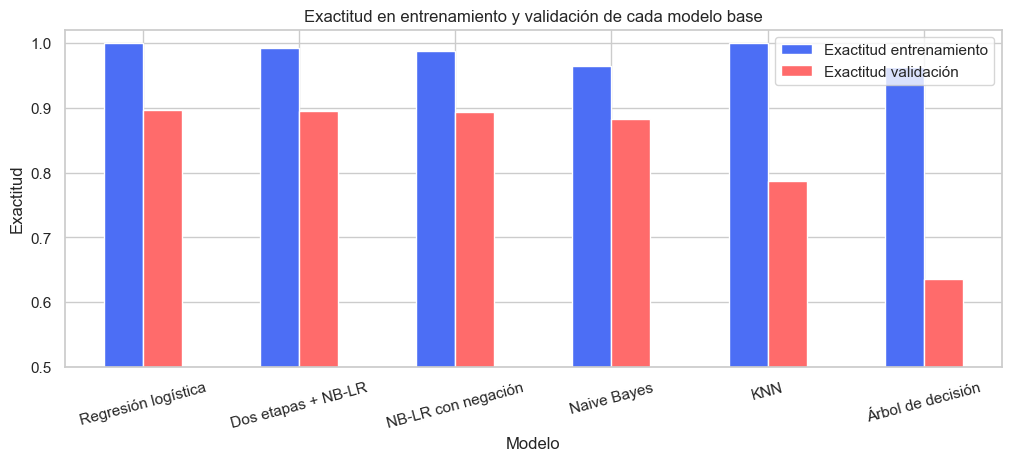

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
tabla_base[['Exactitud entrenamiento', 'Exactitud validación']].plot(kind='bar', ax=ax, color=['#4C6EF5', '#FF6B6B'])
ax.set(ylabel='Exactitud', ylim=(0.5, 1.02), title='Exactitud en entrenamiento y validación de cada modelo base')
plt.xticks(rotation=15)
plt.show()

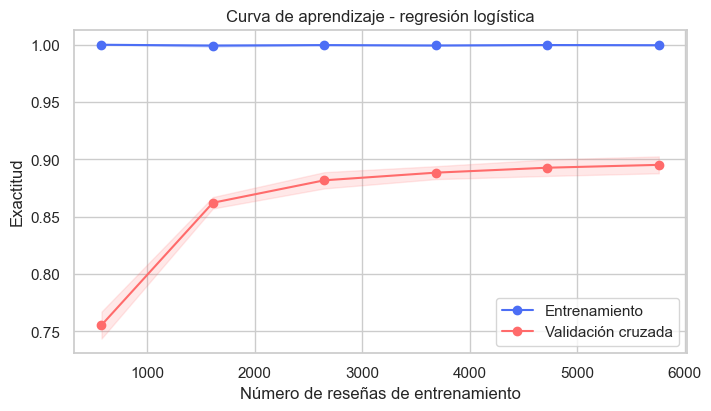

Exactitud de validación cruzada por tamaño: {np.int64(576): np.float64(0.7556), np.int64(1612): np.float64(0.8622), np.int64(2649): np.float64(0.8818), np.int64(3686): np.float64(0.8885), np.int64(4723): np.float64(0.8928), np.int64(5760): np.float64(0.8953)}


In [13]:
# Curva de aprendizaje de la regresión logística: cómo cambian las exactitudes al aumentar los datos de entrenamiento
tamanos, exact_ent, exact_val = learning_curve(clone(modelos_base['Regresión logística']), X_train, y_train,
                                               train_sizes=np.linspace(0.1, 1.0, 6), cv=kfold,
                                               scoring='accuracy', n_jobs=-1)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for valores, etiqueta, color in [(exact_ent, 'Entrenamiento', '#4C6EF5'), (exact_val, 'Validación cruzada', '#FF6B6B')]:
    ax.plot(tamanos, valores.mean(axis=1), marker='o', color=color, label=etiqueta)
    ax.fill_between(tamanos, valores.mean(axis=1) - valores.std(axis=1), valores.mean(axis=1) + valores.std(axis=1), color=color, alpha=0.15)
ax.set(xlabel='Número de reseñas de entrenamiento', ylabel='Exactitud', title='Curva de aprendizaje - regresión logística')
ax.legend()
plt.show()
print('Exactitud de validación cruzada por tamaño:', dict(zip(tamanos, exact_val.mean(axis=1).round(4))))

**Modelos lineales y probabilísticos.** La regresión logística, el modelo en dos etapas, NB-LR y Naive Bayes llegan a una exactitud de entre 0,96 y 1,00 en entrenamiento y de entre 0,88 y 0,90 en validación. Su **sesgo es bajo**: pueden representar casi perfectamente las reseñas de entrenamiento. La diferencia de 8 a 10 puntos con validación indica **varianza**, aunque no toda esa diferencia es sobreajuste. Parte del error de validación viene de reseñas ambiguas, con dos opiniones contrarias y un cierre como "ni fu ni fa", que ningún modelo puede acertar con seguridad (en los notebooks anteriores producían cerca del 40% de los errores).

**Árbol y KNN.** Muestran el sobreajuste más fuerte. KNN con pesos por distancia memoriza el entrenamiento (1,00) y baja a 0,79 en validación. El árbol baja de 0,96 a 0,64: además de sobreajustar, generaliza mal, porque cada división usa una sola palabra de entre más de 70.000.

**Curva de aprendizaje.** La exactitud de validación de la regresión logística sube rápido al principio (de 0,756 con 576 reseñas a 0,882 con 2.649) y después se aplana (de 0,893 a 0,895 entre 4.723 y 5.760 reseñas). Más datos del mismo tipo ayudarían poco; el límite está más en la ambigüedad de las reseñas que en la cantidad de datos.

### 5.2 Sesgo entre clases

El sesgo también puede entenderse como una inclinación sistemática hacia alguna clase. Para cada modelo se compara, en validación, la proporción de reseñas que predice de cada clase con la proporción real, cuántas reseñas negativas clasifica como positivas y al revés, y la sensibilidad (recall) de cada clase.

In [14]:
y_val_arr = y_val.values
filas = [{'Modelo': 'Real (validación)', **{f'% {c}': (y_val_arr == c).mean() for c in ORDEN_CLASES}}]
for nombre in tabla_base.index:
    pred = a_etiquetas(prob[nombre]['validación'])
    fila = {'Modelo': nombre}
    fila.update({f'% {c}': (pred == c).mean() for c in ORDEN_CLASES})
    fila['negativo → positivo'] = int(((y_val_arr == 'negativo') & (pred == 'positivo')).sum())
    fila['positivo → negativo'] = int(((y_val_arr == 'positivo') & (pred == 'negativo')).sum())
    fila.update({f'Sensibilidad {c}': ((pred == c) & (y_val_arr == c)).sum() / (y_val_arr == c).sum() for c in ORDEN_CLASES})
    filas.append(fila)
pd.DataFrame(filas).set_index('Modelo').round(3)

,% negativo,% neutral,% positivo,negativo → positivo,positivo → negativo,Sensibilidad negativo,Sensibilidad neutral,Sensibilidad positivo
Modelo,,,,,,,,
Real (validación),0.351,0.298,0.351,NaN,NaN,NaN,NaN,NaN
Regresión logística,0.337,0.304,0.359,128.0,99.0,0.842,0.996,0.867
Dos etapas + NB-LR,0.340,0.300,0.359,130.0,109.0,0.841,0.996,0.865
NB-LR con negación,0.338,0.306,0.356,131.0,108.0,0.835,1.000,0.859
Naive Bayes,0.327,0.316,0.358,135.0,97.0,0.816,0.996,0.854
KNN,0.327,0.334,0.339,207.0,193.0,0.701,0.983,0.707
Árbol de decisión,0.323,0.295,0.382,333.0,274.0,0.520,0.808,0.604


Ningún modelo tiene problemas con la clase `neutral` (sensibilidad entre 0,98 y 1,00, salvo el árbol). En cambio, los cuatro mejores modelos tienen un **sesgo leve hacia `positivo`**: predicen entre 35,6% y 35,9% de reseñas positivas cuando la proporción real es de 35,1%, y entre 32,7% y 34,0% de negativas frente a 35,1% real. Por eso confunden más reseñas negativas como positivas (128 a 135) que al revés (97 a 109), y su sensibilidad en `negativo` (0,82 a 0,84) es menor que en `positivo` (0,85 a 0,87).

El sesgo es pequeño (cerca de 30 reseñas de 2.400). En la búsqueda de hiperparámetros, `class_weight='balanced'` no mejoró la regresión logística, así que no se corrige por esa vía.

## 6. Ensambles

### 6.1 Random Forest

In [15]:
inicio = time.time()
busqueda_rf = GridSearchCV(
    Pipeline([('rep', construir_representacion_corregida()), ('modelo', RandomForestClassifier(random_state=RANDOM_STATE))]),
    {'modelo__n_estimators': [200, 400], 'modelo__max_depth': [10, None],
     'modelo__min_samples_leaf': [1, 5], 'modelo__class_weight': [None, 'balanced']},
    cv=kfold, scoring='accuracy', n_jobs=-1)
busqueda_rf.fit(X_train, y_train)
print(f'Random Forest: {busqueda_rf.best_params_} | exactitud CV {busqueda_rf.best_score_:.4f} | {time.time() - inicio:.0f} s')

Random Forest: {'modelo__class_weight': None, 'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 400} | exactitud CV 0.7604 | 249 s


El mejor Random Forest usa 400 árboles, sin límite de profundidad y hojas de una sola reseña, con una exactitud de 0,760 en validación cruzada. Es muy inferior a los modelos lineales (0,895). Con más de 70.000 atributos dispersos, cada árbol solo ve una pequeña parte de las palabras y necesita muchas divisiones para captar opiniones que una regresión logística resume en pocos coeficientes.

### 6.2 Gradient Boosting

`GradientBoostingClassifier` sobre las más de 70.000 columnas dispersas del TF-IDF tardaría horas. Por eso se usa `HistGradientBoostingClassifier`, la versión rápida de gradient boosting de scikit-learn, sobre una versión reducida de la representación: `TruncatedSVD` (análisis semántico latente) la resume en 300 componentes. Se buscan los mismos hiperparámetros de la práctica (número de árboles, tasa de aprendizaje y profundidad) y se usan pesos balanceados por clase (`class_weight='balanced'`), equivalentes a los pesos balanceados por registro de la práctica.

In [16]:
inicio = time.time()
busqueda_gb = GridSearchCV(
    Pipeline([('rep', construir_representacion_corregida()),
              ('svd', TruncatedSVD(n_components=300, random_state=RANDOM_STATE)),
              ('modelo', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE))]),
    {'modelo__max_iter': [100, 300], 'modelo__learning_rate': [0.05, 0.1], 'modelo__max_depth': [2, 3, 4]},
    cv=kfold, scoring='accuracy', n_jobs=-1)
busqueda_gb.fit(X_train, y_train)
print(f'Gradient Boosting: {busqueda_gb.best_params_} | exactitud CV {busqueda_gb.best_score_:.4f} | {time.time() - inicio:.0f} s')
res_gb = pd.DataFrame(busqueda_gb.cv_results_)
res_gb.pivot_table(index='param_modelo__max_iter', columns='param_modelo__learning_rate', values='mean_test_score', aggfunc='max').round(4)

Gradient Boosting: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 4, 'modelo__max_iter': 300} | exactitud CV 0.7844 | 409 s


param_modelo__learning_rate,0.05,0.10
param_modelo__max_iter,,
100,0.7626,0.7711
300,0.7769,0.7844


La mejor configuración usa una tasa de aprendizaje de 0,1, 300 iteraciones y profundidad 4, con una exactitud de 0,784 en validación cruzada. En la tabla se ve la relación entre la tasa de aprendizaje y el número de árboles: con más iteraciones el resultado mejora en ambas tasas, y con la tasa menor (0,05) hacen falta más iteraciones para llegar al mismo nivel. La mejor combinación quedó en el borde de la grilla, así que más iteraciones podrían mejorarlo algo, pero sigue muy lejos de los modelos lineales: al resumir el texto en 300 componentes se pierden matices de palabras concretas.

### 6.3 Votación con los mejores modelos

Para elegir qué modelos votan se ordenan los modelos base por su exactitud en validación y se prueban votaciones con los 2, 3, 4, 5 y 6 mejores, tanto **dura** (cada modelo vota por una clase y gana la más votada) como **suave** (se promedian las probabilidades).

Como los modelos ya están entrenados, la votación se calcula directamente con sus probabilidades, lo que da exactamente el mismo resultado que un `VotingClassifier` con esos modelos, pero sin volver a entrenarlos para cada combinación (el modelo en dos etapas tarda varios minutos). Para el envío final, la votación elegida se construye como un `VotingClassifier` de scikit-learn y se entrena con todos los datos.

In [17]:
ranking = list(tabla_base.index)     # modelos base ordenados por exactitud de validación


def votar(nombres, conjunto, tipo):
    """Votación con modelos ya entrenados: 'suave' promedia probabilidades, 'dura' cuenta votos (como VotingClassifier)."""
    probabilidades = [prob[n][conjunto] for n in nombres]
    if tipo == 'suave':
        promedio = np.mean(probabilidades, axis=0)
        return promedio, a_etiquetas(promedio)
    votos = np.stack([p.argmax(axis=1) for p in probabilidades], axis=1)
    ganadores = np.array([np.bincount(v, minlength=len(ORDEN_CLASES)).argmax() for v in votos])
    return None, np.array(ORDEN_CLASES)[ganadores]


filas = []
for k in range(2, len(ranking) + 1):
    nombres = ranking[:k]
    for tipo in ['dura', 'suave']:
        p_val, pred_val = votar(nombres, 'validación', tipo)
        p_ent, pred_ent = votar(nombres, 'entrenamiento', tipo)
        filas.append({'Votación': f'{tipo} - {k} mejores', 'Modelos': ', '.join(nombres), 'tipo': tipo, 'k': k,
                      'Exactitud entrenamiento': accuracy_score(y_train, pred_ent),
                      'Exactitud validación': accuracy_score(y_val, pred_val),
                      'F1 validación': f1_score(y_val, pred_val, average='macro')})
tabla_vot = pd.DataFrame(filas).set_index('Votación')
display(tabla_vot.drop(columns=['tipo', 'k']).round(4))

mejor_suave = tabla_vot[tabla_vot['tipo'] == 'suave']['Exactitud validación'].idxmax()
modelos_votacion = ranking[:int(tabla_vot.loc[mejor_suave, 'k'])]
print('Mejor votación suave:', mejor_suave, '->', modelos_votacion)

,Modelos,Exactitud entrenamiento,Exactitud validación,F1 validación
Votación,,,,
dura - 2 mejores,"Regresión logística, Dos etapas + NB-LR",0.9960,0.8971,0.9014
suave - 2 mejores,"Regresión logística, Dos etapas + NB-LR",0.9975,0.8996,0.9041
dura - 3 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación",0.9938,0.8975,0.9020
suave - 3 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación",0.9960,0.8992,0.9036
dura - 4 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación, Naive Bayes",0.9924,0.8971,0.9013
suave - 4 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación, Naive Bayes",0.9900,0.8950,0.8995
dura - 5 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación, Naive Bayes, KNN",0.9946,0.8942,0.8983
suave - 5 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación, Naive Bayes, KNN",0.9978,0.8917,0.8956
dura - 6 mejores,"Regresión logística, Dos etapas + NB-LR, NB-LR con negación, Naive Bayes, KNN, Árbol de decisión",0.9965,0.8967,0.9004


Mejor votación suave: suave - 2 mejores -> ['Regresión logística', 'Dos etapas + NB-LR']


In [18]:
# ¿Qué tan distintos son los errores de los mejores modelos? % de los errores de la fila que también comete la columna
mejores = ranking[:4]
errores = {n: a_etiquetas(prob[n]['validación']) != y_val_arr for n in mejores}
matriz = pd.DataFrame({b: {a: (errores[a] & errores[b]).sum() / errores[a].sum() for a in mejores} for b in mejores})
print('Errores en validación:', {n: int(e.sum()) for n, e in errores.items()})
matriz.round(2)

Errores en validación: {'Regresión logística': 248, 'Dos etapas + NB-LR': 251, 'NB-LR con negación': 258, 'Naive Bayes': 281}


,Regresión logística,Dos etapas + NB-LR,NB-LR con negación,Naive Bayes
Regresión logística,1.00,0.83,0.75,0.66
Dos etapas + NB-LR,0.82,1.00,0.85,0.76
NB-LR con negación,0.72,0.83,1.00,0.76
Naive Bayes,0.58,0.68,0.70,1.00


**¿Qué votación obtiene la mayor exactitud y F1 de validación?** La votación **suave con los 2 mejores modelos** (regresión logística y dos etapas + NB-LR), con 0,8996 de exactitud y 0,9041 de F1. Agregar NB-LR casi no cambia nada (0,8992) y agregar Naive Bayes, KNN y el árbol empeora el resultado, porque los modelos débiles añaden errores que los buenos no cometen.

**¿Por qué la votación suave rinde más que la dura?** La suave tiene en cuenta la confianza de cada modelo: si uno está muy seguro y otro duda, gana el seguro. En la dura todos los votos pesan igual, y con un número par de modelos los empates se resuelven por orden de clase.

**Diversidad.** La matriz muestra que los mejores modelos se equivocan casi en las mismas reseñas: el 83% de los errores de la regresión logística también los comete el modelo en dos etapas. Naive Bayes es más distinto (comparte entre 58% y 70% de los errores de los otros), pero es más débil. Con tan poca diversidad, la votación solo puede corregir unas pocas reseñas.

### 6.4 Stacking

El stacking combina regresión logística, Naive Bayes, NB-LR con negación y una SVM lineal, con una regresión logística como meta-modelo. Como en la práctica, se buscan la regularización (`C`) y el `class_weight` del meta-modelo. El modelo en dos etapas no se incluye porque `StackingClassifier` entrena cada modelo base varias veces (una por cada partición interna) y con él cada ajuste tardaría demasiado.

In [19]:
inicio = time.time()
estimadores_stacking = [
    ('regresion', clone(modelos_base['Regresión logística'])),
    ('bayes', clone(modelos_base['Naive Bayes'])),
    ('nblr', clone(modelos_base['NB-LR con negación'])),
    ('svm', Pipeline([('rep', construir_representacion_corregida()), ('modelo', LinearSVC(C=0.3, random_state=RANDOM_STATE))])),
]
busqueda_stack = GridSearchCV(
    StackingClassifier(estimadores_stacking, final_estimator=LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), cv=5),
    {'final_estimator__C': [0.1, 1, 10], 'final_estimator__class_weight': [None, 'balanced']},
    cv=kfold, scoring='accuracy', n_jobs=-1)
busqueda_stack.fit(X_train, y_train)
print(f'Stacking: {busqueda_stack.best_params_} | exactitud CV {busqueda_stack.best_score_:.4f} | {time.time() - inicio:.0f} s')

Stacking: {'final_estimator__C': 10, 'final_estimator__class_weight': 'balanced'} | exactitud CV 0.8978 | 437 s


## 7. Comparación de los ensambles en entrenamiento y validación

Exactitud  Precisión  Sensibilidad      F1     AUC      AP
Ensamble                   Conjunto                                                                 
Random Forest              entrenamiento     1.0000     1.0000        1.0000  1.0000  1.0000  1.0000
                           validación        0.7762     0.7774        0.7873  0.7813  0.9048  0.8261
Gradient Boosting          entrenamiento     1.0000     1.0000        1.0000  1.0000  1.0000  1.0000
                           validación        0.8025     0.8104        0.8114  0.8082  0.9312  0.8769
Votación suave (2 mejores) entrenamiento     0.9975     0.9976        0.9976  0.9976  1.0000  1.0000
                           validación        0.8996     0.9041        0.9045  0.9041  0.9816  0.9680
Stacking                   entrenamiento     0.9926     0.9930        0.9930  0.9930  0.9998  0.9997
                           validación        0.8967     0.9010        0.9017  0.9012  0.9808  0.9657

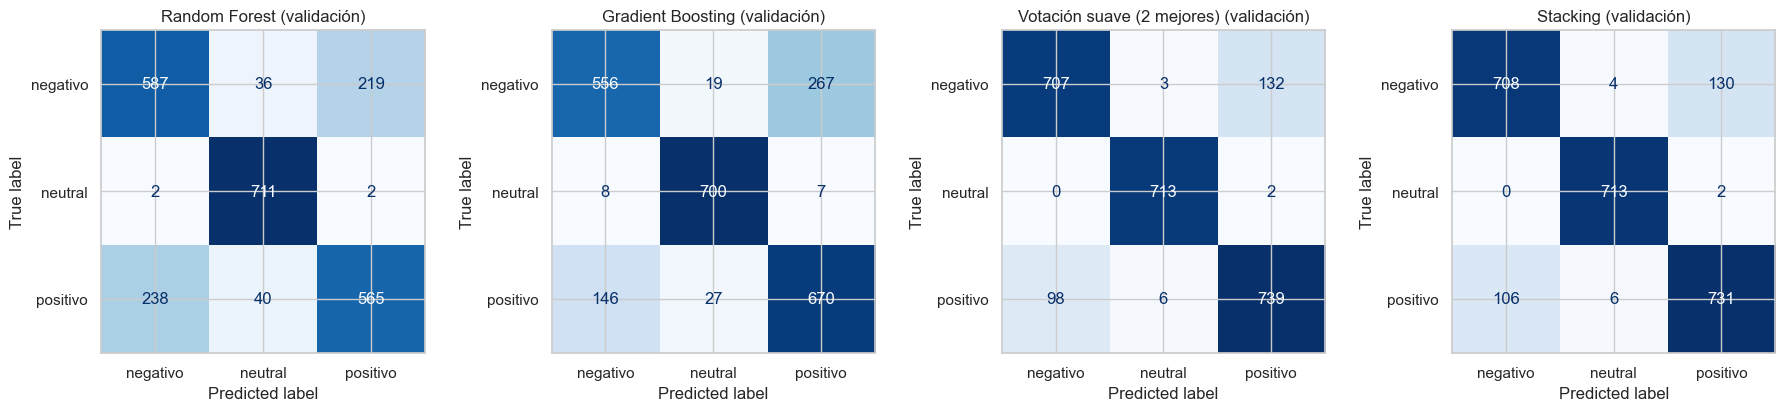

In [20]:
ensambles = {'Random Forest': busqueda_rf.best_estimator_, 'Gradient Boosting': busqueda_gb.best_estimator_,
             'Stacking': busqueda_stack.best_estimator_}
for nombre, modelo in ensambles.items():
    prob[nombre] = {'entrenamiento': modelo.predict_proba(X_train), 'validación': modelo.predict_proba(X_val)}
nombre_votacion = f'Votación suave ({len(modelos_votacion)} mejores)'
prob[nombre_votacion] = {c: votar(modelos_votacion, c, 'suave')[0] for c in ['entrenamiento', 'validación']}
nombres_ensambles = ['Random Forest', 'Gradient Boosting', nombre_votacion, 'Stacking']

filas = []
for nombre in nombres_ensambles:
    for conjunto, y_real in [('entrenamiento', y_train), ('validación', y_val)]:
        filas.append({'Ensamble': nombre, 'Conjunto': conjunto, **metricas(y_real, prob[nombre][conjunto])})
tabla_ens = pd.DataFrame(filas).set_index(['Ensamble', 'Conjunto'])
display(tabla_ens.round(4))

fig, ax = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)
for eje, nombre in zip(ax, nombres_ensambles):
    ConfusionMatrixDisplay.from_predictions(y_val, a_etiquetas(prob[nombre]['validación']), labels=ORDEN_CLASES,
                                            cmap='Blues', ax=eje, colorbar=False)
    eje.set_title(f'{nombre} (validación)')
plt.show()

**¿Qué ensamble muestra más sobreajuste?** Random Forest y Gradient Boosting: aciertan el 100% de las reseñas de entrenamiento y solo entre el 78% y el 80% de las de validación. La votación y el stacking tienen el mismo patrón que los modelos lineales que combinan (cerca de 0,99 en entrenamiento y 0,90 en validación).

En validación, la votación suave obtiene la mayor exactitud (0,8996), la mayor AUC (0,9816) y la mayor AP (0,9680). El stacking, con regresión logística final (`C = 10`, `class_weight='balanced'`), queda igual que la regresión logística sola (0,8967): como sus modelos base cometen casi los mismos errores, el meta-modelo tiene poco que corregir. Por eso conviene que los modelos base sean diferentes entre sí.

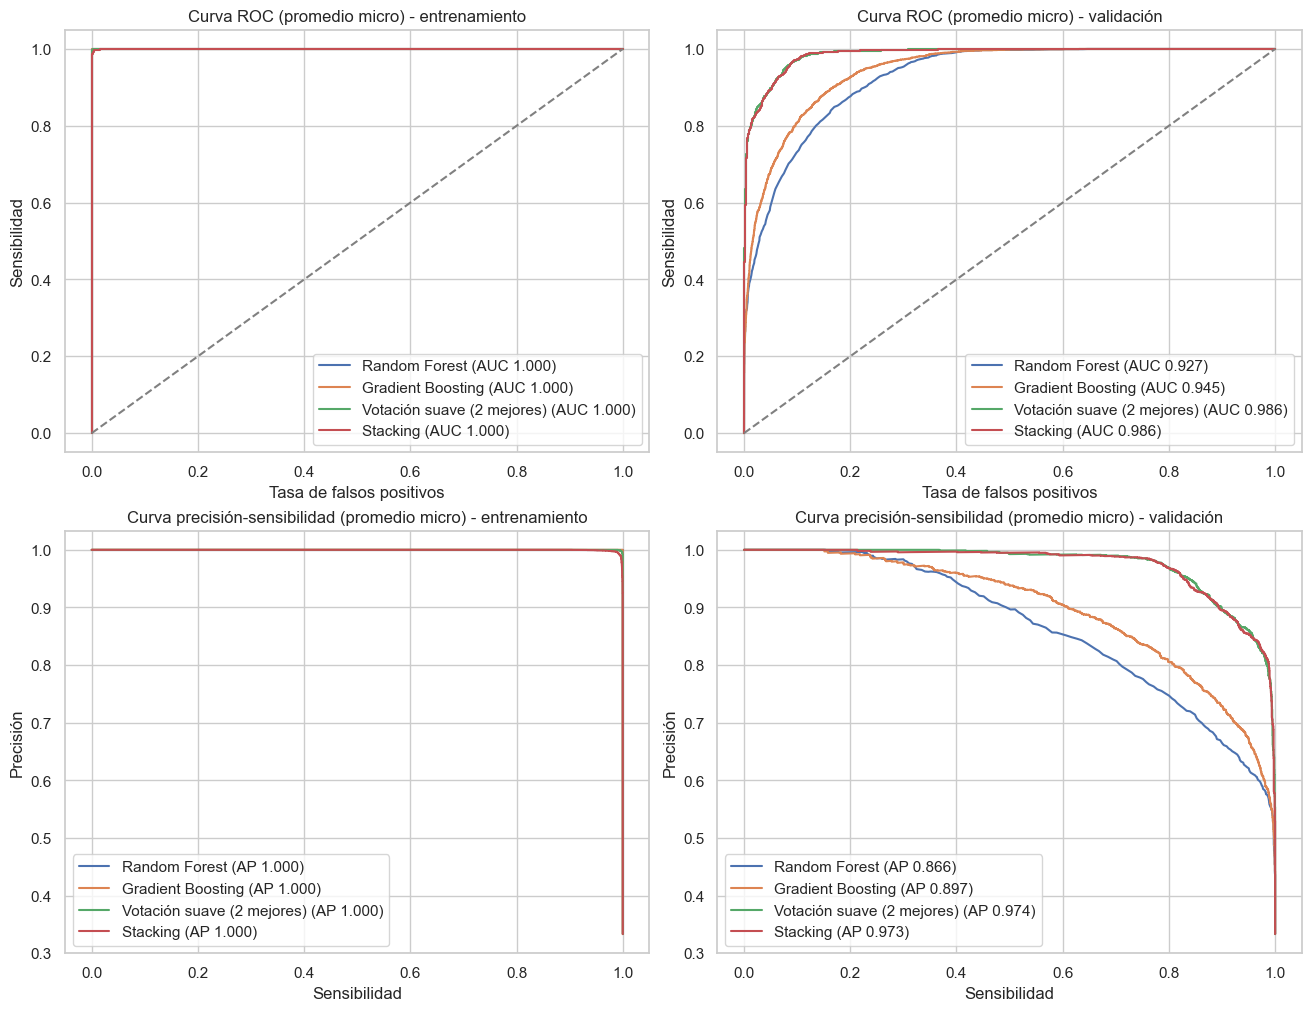

In [21]:
def curva_micro(y_real, probabilidades):
    Y = label_binarize(y_real, classes=ORDEN_CLASES)
    return Y.ravel(), probabilidades.ravel()


fig, ax = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for j, (conjunto, y_real) in enumerate([('entrenamiento', y_train), ('validación', y_val)]):
    for nombre in nombres_ensambles:
        y_bin, p = curva_micro(y_real, prob[nombre][conjunto])
        fpr, tpr, _ = roc_curve(y_bin, p)
        precision, sensibilidad, _ = precision_recall_curve(y_bin, p)
        ax[0, j].plot(fpr, tpr, label=f'{nombre} (AUC {roc_auc_score(y_bin, p):.3f})')
        ax[1, j].plot(sensibilidad, precision, label=f'{nombre} (AP {average_precision_score(y_bin, p):.3f})')
    ax[0, j].plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax[0, j].set(title=f'Curva ROC (promedio micro) - {conjunto}', xlabel='Tasa de falsos positivos', ylabel='Sensibilidad')
    ax[1, j].set(title=f'Curva precisión-sensibilidad (promedio micro) - {conjunto}', xlabel='Sensibilidad', ylabel='Precisión')
    ax[0, j].legend(loc='lower right')
    ax[1, j].legend(loc='lower left')
plt.show()

## 8. Tabla comparativa en validación y selección

In [22]:
mejor_base = tabla_base.index[0]
candidatos_finales = nombres_ensambles + [mejor_base]
tabla_val = pd.DataFrame({n: metricas(y_val, prob[n]['validación']) for n in candidatos_finales}).T
tabla_val.index = [f'{n} (mejor modelo base)' if n == mejor_base else n for n in tabla_val.index]
tabla_val = tabla_val.sort_values('Exactitud', ascending=False)
display(tabla_val.round(4))

elegido = tabla_val['Exactitud'].idxmax().replace(' (mejor modelo base)', '')
print('Modelo elegido (mayor exactitud de validación):', elegido)
print(f'Diferencia frente al mejor modelo base: {tabla_val.loc[tabla_val.index[0], "Exactitud"] - metricas(y_val, prob[mejor_base]["validación"])["Exactitud"]:+.4f}')

,Exactitud,Precisión,Sensibilidad,F1,AUC,AP
Votación suave (2 mejores),0.8996,0.9041,0.9045,0.9041,0.9816,0.9680
Stacking,0.8967,0.9010,0.9017,0.9012,0.9808,0.9657
Regresión logística (mejor modelo base),0.8967,0.9002,0.9017,0.9008,0.9793,0.9656
Gradient Boosting,0.8025,0.8104,0.8114,0.8082,0.9312,0.8769
Random Forest,0.7762,0.7774,0.7873,0.7813,0.9048,0.8261


Modelo elegido (mayor exactitud de validación): Votación suave (2 mejores)
Diferencia frente al mejor modelo base: +0.0029


Se elige la **votación suave con los 2 mejores modelos**, que tiene la mayor exactitud de validación: 0,8996, frente a 0,8967 del mejor modelo base (la regresión logística).

**¿Los ensambles mejoran al mejor modelo básico?** Solo la votación, y por poco: +0,29 puntos, unas 7 reseñas de 2.400, menos que el error estándar de la validación (cerca de 0,6 puntos). El stacking lo iguala y Random Forest y Gradient Boosting quedan muy por debajo.

**¿Justifica el costo?** La votación incluye el modelo en dos etapas, así que su entrenamiento tarda minutos en lugar de segundos y es más difícil de interpretar que una regresión logística. Se justifica solo si la mejora se confirma en el conjunto de prueba. Además, al elegir entre varias votaciones y ensambles con el mismo conjunto de validación, el ganador tiende a verse un poco mejor de lo que es, y la prueba corrige esa ventaja.

## 9. Evaluación en el conjunto de prueba

Exactitud  Precisión  Sensibilidad      F1     AUC      AP
Modelo                     Conjunto                                                              
Votación suave (2 mejores) validación     0.8996     0.9041        0.9045  0.9041  0.9816  0.9680
                           prueba         0.9025     0.9066        0.9074  0.9070  0.9822  0.9679
Regresión logística        validación     0.8967     0.9002        0.9017  0.9008  0.9793  0.9656
                           prueba         0.8946     0.8974        0.8998  0.8985  0.9791  0.9639

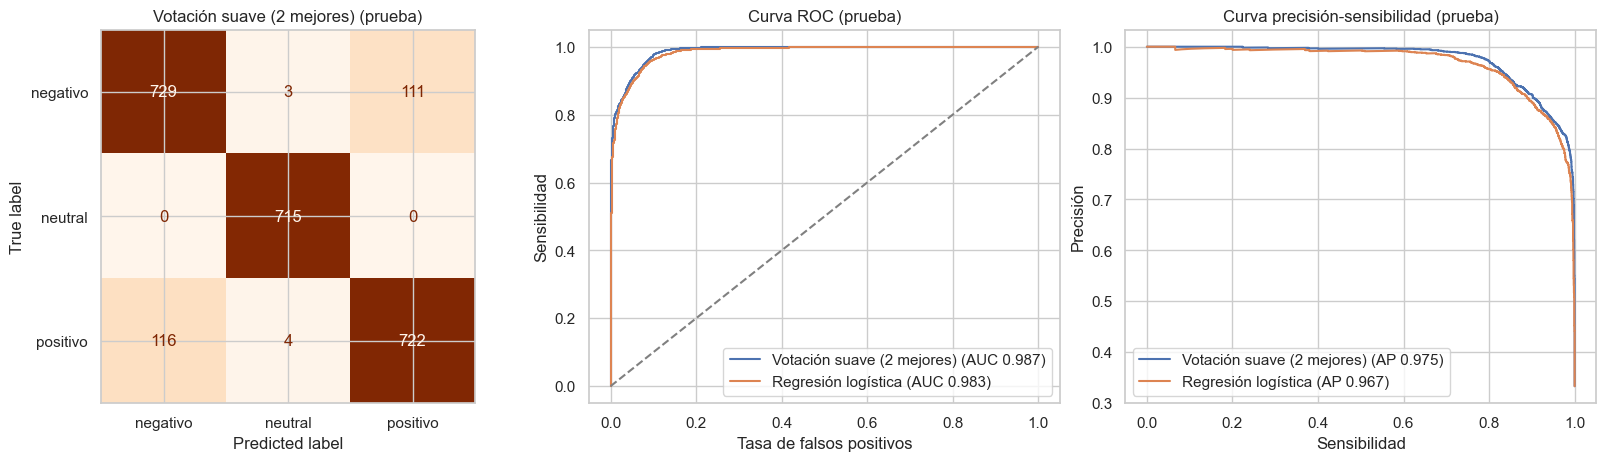

In [23]:
def probabilidades_prueba(nombre):
    if nombre == nombre_votacion:
        return np.mean([modelos_base[n].predict_proba(X_test) for n in modelos_votacion], axis=0)
    if nombre in ensambles:
        return ensambles[nombre].predict_proba(X_test)
    return modelos_base[nombre].predict_proba(X_test)


evaluados = [elegido] if elegido == mejor_base else [elegido, mejor_base]
prob_test = {n: probabilidades_prueba(n) for n in evaluados}
filas = []
for n in evaluados:
    filas.append({'Modelo': n, 'Conjunto': 'validación', **metricas(y_val, prob[n]['validación'])})
    filas.append({'Modelo': n, 'Conjunto': 'prueba', **metricas(y_test, prob_test[n])})
display(pd.DataFrame(filas).set_index(['Modelo', 'Conjunto']).round(4))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, a_etiquetas(prob_test[elegido]), labels=ORDEN_CLASES, cmap='Oranges', ax=ax[0], colorbar=False)
ax[0].set_title(f'{elegido} (prueba)')
for n in evaluados:
    y_bin, p = curva_micro(y_test, prob_test[n])
    fpr, tpr, _ = roc_curve(y_bin, p)
    precision, sensibilidad, _ = precision_recall_curve(y_bin, p)
    ax[1].plot(fpr, tpr, label=f'{n} (AUC {roc_auc_score(y_bin, p):.3f})')
    ax[2].plot(sensibilidad, precision, label=f'{n} (AP {average_precision_score(y_bin, p):.3f})')
ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[1].set(title='Curva ROC (prueba)', xlabel='Tasa de falsos positivos', ylabel='Sensibilidad')
ax[2].set(title='Curva precisión-sensibilidad (prueba)', xlabel='Sensibilidad', ylabel='Precisión')
ax[1].legend(loc='lower right')
ax[2].legend(loc='lower left')
plt.show()

En el conjunto de prueba la votación obtiene una exactitud de **0,9025** y un F1 de 0,9070, incluso algo más que en validación (0,8996 y 0,9041), así que las métricas se mantienen. La regresión logística sola obtiene 0,8946, un poco menos que en validación (0,8967). La ventaja de la votación es de 0,79 puntos en prueba (unas 19 reseñas de 2.400) y de 0,29 en validación. Ambas van en el mismo sentido, lo que sugiere que la mejora es real aunque pequeña.

## 10. Modelo final y predicciones para la competencia

El modelo elegido se vuelve a entrenar con las 12.000 reseñas etiquetadas (entrenamiento, validación y prueba juntos), ya que más datos suelen dar un modelo un poco mejor, y con él se predicen las reseñas de `eval.csv` para la competencia. Los hiperparámetros no se vuelven a buscar.

In [24]:
nombres_archivo = {nombre_votacion: 'votacion_suave_mejores', 'Random Forest': 'random_forest_bloques',
                   'Gradient Boosting': 'gradient_boosting_lsa', 'Stacking': 'stacking_bloques',
                   'Dos etapas + NB-LR': 'dos_etapas_nblr_m8', 'NB-LR con negación': 'nblr_negacion',
                   'Regresión logística': 'regresion_logistica_m8', 'Naive Bayes': 'naive_bayes_m8'}
NOMBRE_MODELO = nombres_archivo.get(elegido, 'modelo_elegido_m8')

if elegido == nombre_votacion:
    modelo_final = VotingClassifier([(f'm{i}', clone(modelos_base[n])) for i, n in enumerate(modelos_votacion)], voting='soft')
elif elegido in ensambles:
    modelo_final = clone(ensambles[elegido])
else:
    modelo_final = clone(modelos_base[elegido])

inicio = time.time()
modelo_final.fit(X, y)       # las 12.000 reseñas etiquetadas
print(f'{elegido} entrenado con las 12.000 reseñas en {time.time() - inicio:.0f} s')

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)
print('Archivo:', f'submission_{NOMBRE_MODELO}.csv')
print('Mismas columnas y mismos ids que sample_submission:',
      list(envio.columns) == list(muestra_envio.columns) and (envio['id'] == muestra_envio['id']).all())

for archivo in ['submission_dos_etapas_nblr.csv', 'submission_regresion_logistica_ajuste_fino.csv', 'submission_regresion_logistica_bloques.csv']:
    ruta = os.path.join(RUTA_ENVIOS, archivo)
    if os.path.exists(ruta):
        print(f'Predicciones distintas respecto a {archivo}: {(envio["answer"] != pd.read_csv(ruta)["answer"]).sum()} de {len(envio)}')
display(pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                      'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

Votación suave (2 mejores) entrenado con las 12.000 reseñas en 122 s


Archivo: submission_votacion_suave_mejores.csv
Mismas columnas y mismos ids que sample_submission: True
Predicciones distintas respecto a submission_dos_etapas_nblr.csv: 69 de 3000
Predicciones distintas respecto a submission_regresion_logistica_ajuste_fino.csv: 75 de 3000
Predicciones distintas respecto a submission_regresion_logistica_bloques.csv: 77 de 3000


,train (real),eval (predicho)
negativo,0.351,0.356
neutral,0.298,0.279
positivo,0.351,0.364


In [25]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)
print('El modelo guardado reproduce exactamente las mismas predicciones:',
      (modelo_cargado.predict(evaluacion[['text']]) == pred_eval).all())

El modelo guardado reproduce exactamente las mismas predicciones: True


La votación final se entrenó con las 12.000 reseñas en algo más de 6 minutos. Su envío (`submission_votacion_suave_mejores.csv`) cambia 69 de las 3.000 predicciones respecto al envío de dos etapas + NB-LR (el mejor puntaje público hasta ahora, 0,9077), 75 respecto al del ajuste fino y 77 respecto al modelo del notebook principal. La distribución de clases predichas es parecida a la de entrenamiento. Con tan pocas diferencias, en el puntaje público de 900 reseñas se espera un resultado parecido a los anteriores, con variaciones de unas pocas reseñas en cualquier sentido.

## 11. Conclusiones

- **Partición entrenamiento/validación/prueba.** Siguiendo la práctica, los modelos se ajustaron con entrenamiento (60%), se compararon y eligieron con validación (20%) y se evaluaron una sola vez con prueba (20%).
- **Sesgo y varianza.** Los modelos lineales y probabilísticos tienen sesgo bajo y una diferencia de 8 a 10 puntos entre entrenamiento y validación, que mezcla sobreajuste con reseñas que son ambiguas por naturaleza. El árbol, KNN, Random Forest y Gradient Boosting sobreajustan mucho más. La curva de aprendizaje muestra que más datos del mismo tipo ayudarían poco.
- **Sesgo entre clases.** Los mejores modelos se inclinan levemente hacia `positivo` (unas 30 reseñas de 2.400) y no tienen problemas con `neutral`.
- **Ensambles.** De los cuatro ensambles de la práctica, solo la votación suave mejora al mejor modelo base: +0,29 puntos en validación y +0,79 en prueba. El stacking lo iguala. Random Forest y Gradient Boosting rinden mucho peor sobre texto.
- **Mejores modelos a votar.** La mejor votación combina solo los 2 mejores modelos (regresión logística y dos etapas + NB-LR). Agregar modelos más débiles empeora el resultado, y los mejores modelos comparten la mayoría de sus errores, lo que limita lo que cualquier ensamble puede ganar.
- **Modelo para la competencia.** La votación suave de los 2 mejores es un candidato razonable para un nuevo envío; su ventaja sobre dos etapas + NB-LR solo es pequeña.

## 12. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: proponer y generar un primer esqueleto del código de este notebook, depurar errores y redactar las explicaciones.

**Prompts utilizados.**

1. Se compartieron los comentarios del profesor (*"train validation test; medir el sesgo de los modelos; revisar con la práctica ensambles; mejores modelos a votar"*) y el enlace a la Práctica 2, Actividad 4, y se pidió revisarlos.
2. *"si, dale con ese plan"*, para implementar el plan propuesto por la herramienta (partición 60/20/20, medición del sesgo, los cuatro ensambles de la práctica y la votación con los mejores modelos).

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 13. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda aproximadamente 35 minutos (la mayor parte en el stacking, Gradient Boosting y Random Forest).
4. Al terminar se generan `models/votacion_suave_mejores.joblib` y `submissions/submission_votacion_suave_mejores.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`. Para cargar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones y las clases `NBRegresionLogistica` y `ModeloDosEtapasNBLR` usadas por el pipeline.